In [69]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Dropout, TextVectorization, Embedding
from keras.optimizers import AdamW
from keras.losses import SparseCategoricalCrossentropy

import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
import string
import re
import seaborn as sns
from sklearn.metrics import classification_report

In [2]:
print(tf.__version__)

2.21.0


In [3]:
ds_zip_path = "/mnt/e/Deep Learning/data/text-classification/6-persian-topics.zip"

with zipfile.ZipFile(ds_zip_path, 'r') as zip_ref:
    zip_ref.extractall(path="/mnt/e/Deep Learning/data")

In [4]:
ds_path = "/mnt/e/Deep Learning/data/6-persian-topics"

classes = os.listdir(ds_path)
classes

['بهداشت و سلامت',
 'جغرافیا و مکانها',
 'دین و اعتقاد',
 'ریاضیات',
 'فناوری و علوم کاربردی و تکنولوژی',
 'ورزش']

In [5]:
batch_size = 32
SEED = 42

train_ds_raw = tf.keras.utils.text_dataset_from_directory(ds_path, 
                                                          batch_size=batch_size,
                                                          seed=SEED,
                                                          validation_split=0.2,
                                                          subset='training'
                                                          )

val_ds_raw = tf.keras.utils.text_dataset_from_directory(ds_path, 
                                                          batch_size=batch_size,
                                                          seed=SEED,
                                                          validation_split=0.2,
                                                          subset='validation'
                                                          )

Found 37573 files belonging to 6 classes.
Using 30059 files for training.


W0000 00:00:1779509806.176547  785232 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Found 37573 files belonging to 6 classes.
Using 7514 files for validation.


In [6]:
tf.data.experimental.cardinality(train_ds_raw).numpy()  #Number of batches in training set

np.int64(940)

In [7]:
for texts, labels in train_ds_raw.take(1):
    text_file = texts[0].numpy().decode()
    label = labels[0].numpy()

    print(text_file)
    print(train_ds_raw.class_names[label])

آافیر (به لاتین: Aafir) در الجزایر با جمعیت ۱۲٬۶۱۳ نفر است که در استان بومرداس واقع شده‌است.
جغرافیا و مکانها


In [8]:
def custom_standardization(text):
    lower_text = tf.strings.lower(text)
    stripped_html = tf.strings.regex_replace(lower_text, '<br />', ' ')
    stripped_ye = tf.strings.regex_replace(stripped_html, 'ي', 'ی')
    stripped_punc = tf.strings.regex_replace(stripped_ye,
                                  '[%s]' % re.escape(string.punctuation),
                                  '')
    
    return stripped_punc

In [9]:
txt = " براي برای"
print(f"Original Text: {txt}")
print(f"Stripped text: {custom_standardization(txt).numpy().decode()}")

Original Text:  براي برای
Stripped text:  برای برای


In [10]:
max_features = 10000
sequence_length = 250

vectorize_layer = tf.keras.layers.TextVectorization(standardize=custom_standardization,
                                                    max_tokens=max_features,
                                                    output_mode='int',
                                                    output_sequence_length=sequence_length)

In [11]:
vectorize_layer.adapt(train_ds_raw.map(lambda x, y: x))

In [12]:
for texts, labels in train_ds_raw.take(1):
    print(texts.shape)

(32,)


In [13]:
def vectorize_text(text, label):
    text = tf.expand_dims(text, axis=-1)
    vect = vectorize_layer(text)

    return vect, label

In [14]:
train_ds_vect = train_ds_raw.map(vectorize_text)
val_ds_vect = val_ds_raw.map(vectorize_text)

In [15]:
for texts, labels in train_ds_vect.take(1):
    print(texts.shape)
    print(labels)

(32, 250)
tf.Tensor([1 5 4 1 1 1 1 1 1 1 0 5 4 5 5 5 1 4 1 3 1 1 1 4 1 0 1 1 1 1 1 1], shape=(32,), dtype=int32)


In [16]:
train_ds = train_ds_vect.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds_vect.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [17]:
import keras.layers as layers

embedding_dim = 16

model = tf.keras.Sequential([
    layers.Input(shape=(250, )),
    layers.Embedding(max_features, embedding_dim),
    layers.GlobalAveragePooling1D(),
    layers.Dense(100),
    layers.Dropout(0.5),
    layers.Dense(len(train_ds_raw.class_names))])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 16)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │         1,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,306 (634.01 KB)

 Trainable params: 162,306 (634.01 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(loss=SparseCategoricalCrossentropy(from_logits=True),
              optimizer='adam',
              metrics=['accuracy'])

In [19]:
epochs = 15
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs)

Epoch 1/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.7003 - loss: 0.8606 - val_accuracy: 0.8845 - val_loss: 0.3962
Epoch 2/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8889 - loss: 0.3394 - val_accuracy: 0.9038 - val_loss: 0.2634
Epoch 3/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9232 - loss: 0.2351 - val_accuracy: 0.9341 - val_loss: 0.2016
Epoch 4/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9445 - loss: 0.1761 - val_accuracy: 0.9488 - val_loss: 0.1550
Epoch 5/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9572 - loss: 0.1369 - val_accuracy: 0.9574 - val_loss: 0.1324
Epoch 6/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9647 - loss: 0.1128 - val_accuracy: 0.9627 - val_loss: 0.1184
Epoch 7/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9709 - loss: 0.0954 - val_accuracy: 0.9635 - val_loss: 0.1134
Epoch 8/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9748 - loss: 0.0850 - val_accuracy: 

In [20]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

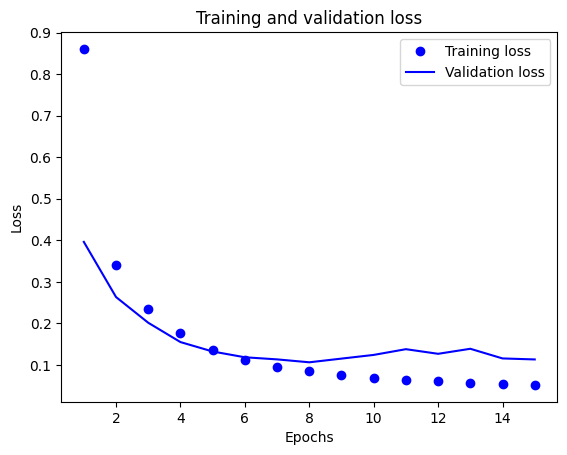

In [21]:
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

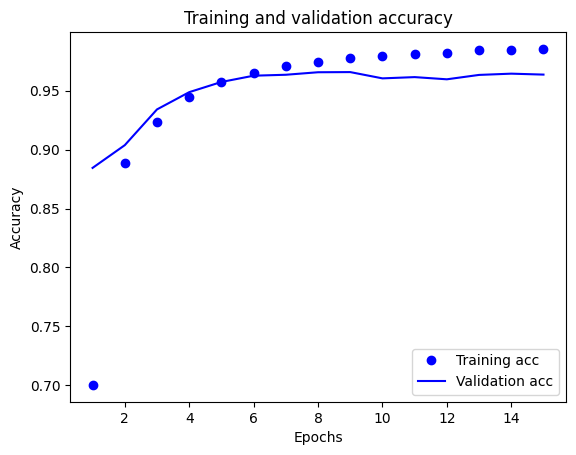

In [22]:
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.show()

____

In [25]:
from keras.models import Sequential
from keras.layers import Activation

export_model = Sequential()
export_model.add(vectorize_layer)
export_model.add(model)
export_model.add(Activation("softmax"))

export_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 250)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 6)              │       162,306 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ ?                      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,306 (634.01 KB)

 Trainable params: 162,306 (634.01 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
export_model.compile(loss=SparseCategoricalCrossentropy(from_logits=False),
                     optimizer=AdamW(learning_rate=0.001),
                     metrics=['acc'])

In [29]:
loss, acc = export_model.evaluate(val_ds_raw)

235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - acc: 0.9637 - loss: 0.1132


In [35]:
text_files_ds = val_ds_raw.map(lambda x, y: x)
labels_ds = val_ds_raw.map(lambda x, y: y)

tf.data.experimental.cardinality(text_files_ds).numpy()
# tf.data.experimental.cardinality(labels_ds).numpy()

np.int64(235)

In [36]:
first_batch_texts = next(iter(text_files_ds))

In [37]:
print(first_batch_texts.shape)

(32,)


In [38]:
first_batch_labels = next(iter(labels_ds))

In [39]:
print(first_batch_labels.shape)

(32,)


In [40]:
predicted_labels = export_model.predict(text_files_ds)
predicted_labels = np.argmax(predicted_labels, axis=1)

235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


In [41]:
predicted_labels

array([0, 1, 4, ..., 1, 1, 1], shape=(7514,))

In [53]:
true_labels = list(labels_ds.as_numpy_iterator())
true_labels = np.concatenate(list(labels_ds.as_numpy_iterator()), axis=0)

In [54]:
true_labels

array([1, 4, 1, ..., 1, 1, 1], shape=(7514,), dtype=int32)

In [56]:
confusion_mat = tf.math.confusion_matrix(true_labels, predicted_labels)
confusion_mat

<tf.Tensor: shape=(6, 6), dtype=int32, numpy=
array([[  11,  219,    6,    1,   74,   71],
       [ 190, 2629,   52,   38,  729,  798],
       [   4,   62,    4,    0,   20,   19],
       [   2,   35,    2,    0,   12,   10],
       [  63,  772,   15,   11,  223,  231],
       [  73,  697,    8,   12,  211,  210]], dtype=int32)>

<Axes: >

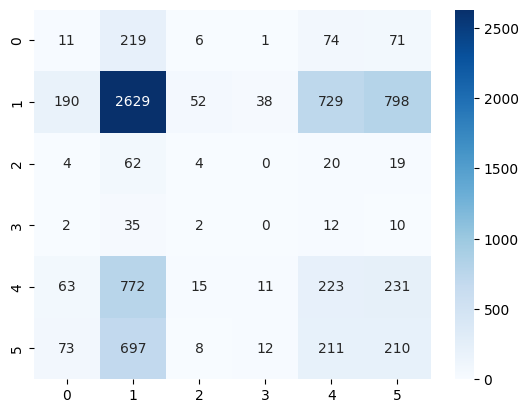

In [68]:
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues')

In [59]:
train_ds_raw.class_names

['بهداشت و سلامت',
 'جغرافیا و مکانها',
 'دین و اعتقاد',
 'ریاضیات',
 'فناوری و علوم کاربردی و تکنولوژی',
 'ورزش']

In [84]:
report = classification_report(true_labels, predicted_labels)
labels = train_ds_raw.class_names

for i in range(len(labels)):
    print(f"{labels[i]} ---> {i}")

بهداشت و سلامت ---> 0
جغرافیا و مکانها ---> 1
دین و اعتقاد ---> 2
ریاضیات ---> 3
فناوری و علوم کاربردی و تکنولوژی ---> 4
ورزش ---> 5


In [79]:
print(report)

              precision    recall  f1-score   support

           0       0.03      0.03      0.03       382
           1       0.60      0.59      0.59      4436
           2       0.05      0.04      0.04       109
           3       0.00      0.00      0.00        61
           4       0.18      0.17      0.17      1315
           5       0.16      0.17      0.16      1211

    accuracy                           0.41      7514
   macro avg       0.17      0.17      0.17      7514
weighted avg       0.41      0.41      0.41      7514



____

## Now we use class weight to fit imbalenced data problem.

In [ ]:
class_num = {}
train_ds_numpy = train_ds.as_numpy_iterator()

for texts, labels in train_ds_numpy:
    for label in labels:
        class_num[label] = class_num.get(label, 0) + 1

In [99]:
class_num = {int(k): v for k, v in class_num.items()}
class_num = dict(sorted(class_num.items()))
class_num

{0: 1534, 1: 17555, 2: 416, 3: 318, 4: 5171, 5: 5065}

In [92]:
train_ds_raw.class_names

['بهداشت و سلامت',
 'جغرافیا و مکانها',
 'دین و اعتقاد',
 'ریاضیات',
 'فناوری و علوم کاربردی و تکنولوژی',
 'ورزش']

In [110]:
sum_samples = np.sum(list(class_num.values()))
sum_samples

class_weight = {}

for key, value in class_num.items():
    class_weight[key] = float(sum_samples / value)

class_weight

{0: 19.595176010430247,
 1: 1.7122757049273711,
 2: 72.25721153846153,
 3: 94.5251572327044,
 4: 5.812995552117579,
 5: 5.934649555774926}

In [111]:
import keras.layers as layers

embedding_dim = 16

model = tf.keras.Sequential([
    layers.Input(shape=(250, )),
    layers.Embedding(max_features, embedding_dim),
    layers.GlobalAveragePooling1D(),
    layers.Dense(100),
    layers.Dropout(0.5),
    layers.Dense(len(train_ds_raw.class_names))])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 250, 16)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │         1,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,306 (634.01 KB)

 Trainable params: 162,306 (634.01 KB)

 Non-trainable params: 0 (0.00 B)

In [112]:
model.compile(loss=SparseCategoricalCrossentropy(from_logits=True),
              optimizer='adam',
              metrics=['accuracy'])

In [113]:
epochs = 15
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs, 
    class_weight=class_weight)

Epoch 1/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5249 - loss: 9.1829 - val_accuracy: 0.8497 - val_loss: 0.6970
Epoch 2/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8654 - loss: 5.2528 - val_accuracy: 0.9087 - val_loss: 0.3636
Epoch 3/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9041 - loss: 3.2822 - val_accuracy: 0.9413 - val_loss: 0.2249
Epoch 4/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9202 - loss: 2.3609 - val_accuracy: 0.9470 - val_loss: 0.1816
Epoch 5/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9333 - loss: 1.7656 - val_accuracy: 0.9567 - val_loss: 0.1463
Epoch 6/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9387 - loss: 1.5695 - val_accuracy: 0.9661 - val_loss: 0.1272
Epoch 7/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9444 - loss: 1.3377 - val_accuracy: 0.9658 - val_loss: 0.1161
Epoch 8/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9518 - loss: 1.1128 - val_accuracy: 0.

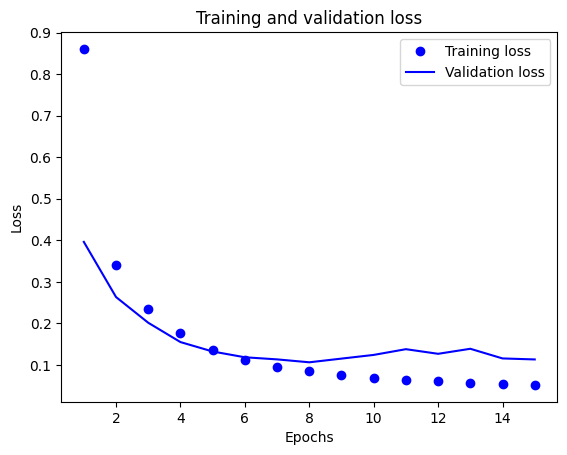

In [114]:
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

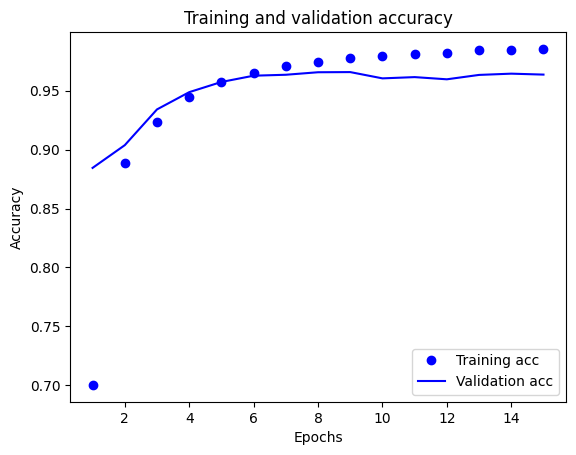

In [115]:
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.show()

In [116]:
from keras.models import Sequential
from keras.layers import Activation

export_model = Sequential()
export_model.add(vectorize_layer)
export_model.add(model)
export_model.add(Activation("softmax"))

export_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 250)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 6)              │       162,306 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ ?                      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,306 (634.01 KB)

 Trainable params: 162,306 (634.01 KB)

 Non-trainable params: 0 (0.00 B)

In [117]:
text_files_ds = val_ds_raw.map(lambda x, y: x)
labels_ds = val_ds_raw.map(lambda x, y: y)

predicted_labels = export_model.predict(text_files_ds)
predicted_labels = np.argmax(predicted_labels, axis=1)

235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step


In [118]:
true_labels = list(labels_ds.as_numpy_iterator())
true_labels = np.concatenate(list(labels_ds.as_numpy_iterator()), axis=0)

In [119]:
confusion_mat = tf.math.confusion_matrix(true_labels, predicted_labels)
confusion_mat

<tf.Tensor: shape=(6, 6), dtype=int32, numpy=
array([[  14,  235,    5,    3,   50,   75],
       [ 237, 2542,   51,   29,  773,  804],
       [   8,   71,    1,    0,   12,   17],
       [   3,   29,    1,    0,   14,   14],
       [  67,  717,   10,    6,  249,  266],
       [  53,  672,   20,    4,  224,  238]], dtype=int32)>

<Axes: >

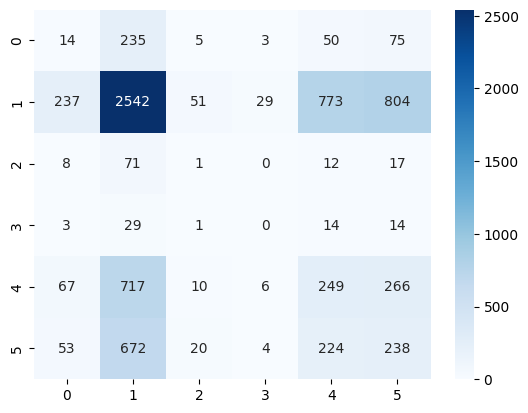

In [120]:
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues')

In [121]:
report = classification_report(true_labels, predicted_labels)
labels = train_ds_raw.class_names

for i in range(len(labels)):
    print(f"{labels[i]} ---> {i}")

بهداشت و سلامت ---> 0
جغرافیا و مکانها ---> 1
دین و اعتقاد ---> 2
ریاضیات ---> 3
فناوری و علوم کاربردی و تکنولوژی ---> 4
ورزش ---> 5


In [122]:
print(report)

              precision    recall  f1-score   support

           0       0.04      0.04      0.04       382
           1       0.60      0.57      0.58      4436
           2       0.01      0.01      0.01       109
           3       0.00      0.00      0.00        61
           4       0.19      0.19      0.19      1315
           5       0.17      0.20      0.18      1211

    accuracy                           0.41      7514
   macro avg       0.17      0.17      0.17      7514
weighted avg       0.41      0.41      0.41      7514

